In [1]:
import pandas as pd 
import numpy as np

df = pd.read_excel('Difference in Statistical Metrics.xlsx') 

df.head()

,game_id,season,game_date,fgm_diff,fga_diff,fg_pct_diff,fg3m_diff,fg3a_diff,fg3_pct_diff,ftm_diff,...,oreb_diff,dreb_diff,reb_diff,ast_diff,stl_diff,blk_diff,tov_diff,pf_diff,pts_diff,home_win
0,42200152,2022,2023-04-19,3,4.0,0.02,4,10.0,0.04,0,...,0.0,2.0,2.0,3.0,-1.0,-1.0,-3.0,1.0,10,1
1,42200151,2022,2023-04-16,-7,-3.0,-0.06,-3,-1.0,-0.07,1,...,-4.0,-7.0,-11.0,-1.0,-1.0,-9.0,-4.0,1.0,-16,0
2,42200167,2022,2023-04-30,-7,-4.0,-0.05,-3,1.0,-0.07,-3,...,-4.0,-2.0,-6.0,-4.0,-1.0,-1.0,1.0,0.0,-20,0
3,42200165,2022,2023-04-26,-8,-6.0,-0.05,-1,-4.0,0.01,10,...,1.0,0.0,1.0,-11.0,-2.0,-4.0,4.0,-6.0,-7,0
4,42200162,2022,2023-04-17,3,10.0,-0.02,-4,-2.0,-0.09,6,...,3.0,-3.0,0.0,4.0,5.0,3.0,-8.0,-1.0,8,1


In [12]:
#Make sure all rows was succesfully transfered from the excel file 

df.shape 

(47928, 22)

In [9]:
# Checking for missing values

df.isnull().mean()

game_id          0.000000
 season          0.000000
 game_date       0.000000
 fgm_diff        0.000000
 fga_diff        0.000522
 fg_pct_diff     0.000522
 fg3m_diff       0.000000
 fg3a_diff       0.055834
 fg3_pct_diff    0.067852
 ftm_diff        0.000000
 fta_diff        0.000000
 ft_pct_diff     0.000000
 oreb_diff       0.060028
 dreb_diff       0.060883
 reb_diff        0.001106
 ast_diff        0.001231
 stl_diff        0.058609
 blk_diff        0.055855
 tov_diff        0.056084
 pf_diff         0.000751
 pts_diff        0.000000
 home_win        0.000000
dtype: float64

In [38]:
# Another way to check for missing values in each column - using numpy 

for col in df.columns:
    pct = round(np.mean(df[col].isnull() * 100),2)
    print(f'{col} -- {pct}% ')

game_id -- 0.0% 
season -- 0.0% 
game_date -- 0.0% 
fgm_diff -- 0.0% 
fga_diff -- 0.05% 
fg_pct_diff -- 0.05% 
fg3m_diff -- 0.0% 
fg3a_diff -- 5.58% 
fg3_pct_diff -- 6.79% 
ftm_diff -- 0.0% 
fta_diff -- 0.0% 
ft_pct_diff -- 0.0% 
oreb_diff -- 6.0% 
dreb_diff -- 6.09% 
reb_diff -- 0.11% 
ast_diff -- 0.12% 
stl_diff -- 5.86% 
blk_diff -- 5.59% 
tov_diff -- 5.61% 
pf_diff -- 0.08% 
pts_diff -- 0.0% 
home_win -- 0.0% 


In [2]:
# In order to keep the dataset more reliable let's remove all missing values from our dataset 
# Columns: (fg3a_diff,fg3_pct_diff,fg3_pct_diff,oreb_diff,dreb_diff,stl_diff,blk_diff,tov_diff)

df_clean = df.dropna()

df_clean.isnull().mean()


game_id          0.0
 season          0.0
 game_date       0.0
 fgm_diff        0.0
 fga_diff        0.0
 fg_pct_diff     0.0
 fg3m_diff       0.0
 fg3a_diff       0.0
 fg3_pct_diff    0.0
 ftm_diff        0.0
 fta_diff        0.0
 ft_pct_diff     0.0
 oreb_diff       0.0
 dreb_diff       0.0
 reb_diff        0.0
 ast_diff        0.0
 stl_diff        0.0
 blk_diff        0.0
 tov_diff        0.0
 pf_diff         0.0
 pts_diff        0.0
 home_win        0.0
dtype: float64

In [41]:
# Check columns data types
df_clean.dtypes

game_id                 object
season                  object
game_date       datetime64[ns]
fgm_diff                 int64
fga_diff               float64
fg_pct_diff            float64
fg3m_diff                int64
fg3a_diff              float64
fg3_pct_diff           float64
ftm_diff                 int64
fta_diff                 int64
ft_pct_diff            float64
oreb_diff              float64
dreb_diff              float64
reb_diff               float64
ast_diff               float64
stl_diff               float64
blk_diff               float64
tov_diff               float64
pf_diff                float64
pts_diff                 int64
home_win                 int64
dtype: object

In [4]:
# Removing the space at the start of each column name 

df_clean.columns = df_clean.columns.str.strip()

print(df.columns)

Index(['game_id', ' season', ' game_date', ' fgm_diff', ' fga_diff',
       ' fg_pct_diff', ' fg3m_diff', ' fg3a_diff', ' fg3_pct_diff',
       ' ftm_diff', ' fta_diff', ' ft_pct_diff', ' oreb_diff', ' dreb_diff',
       ' reb_diff', ' ast_diff', ' stl_diff', ' blk_diff', ' tov_diff',
       ' pf_diff', ' pts_diff', ' home_win'],
      dtype='object')


In [5]:
# Change the dtype for column game_id and season column 

df_clean['game_id'] = df_clean['game_id'].astype('str')

df_clean['season'] = df_clean['season'].astype('str')

df_clean.dtypes

C:\Users\Kiril\AppData\Local\Temp\ipykernel_21084\4013932080.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['game_id'] = df_clean['game_id'].astype('str')
C:\Users\Kiril\AppData\Local\Temp\ipykernel_21084\4013932080.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['season'] = df_clean['season'].astype('str')


game_id                 object
season                  object
game_date       datetime64[ns]
fgm_diff                 int64
fga_diff               float64
fg_pct_diff            float64
fg3m_diff                int64
fg3a_diff              float64
fg3_pct_diff           float64
ftm_diff                 int64
fta_diff                 int64
ft_pct_diff            float64
oreb_diff              float64
dreb_diff              float64
reb_diff               float64
ast_diff               float64
stl_diff               float64
blk_diff               float64
tov_diff               float64
pf_diff                float64
pts_diff                 int64
home_win                 int64
dtype: object

In [6]:
df_clean[['ft_pct_diff','oreb_diff','dreb_diff']].head()

,ft_pct_diff,oreb_diff,dreb_diff
0,0.00,0.0,2.0
1,0.06,-4.0,-7.0
2,-0.04,-4.0,-2.0
3,0.21,1.0,0.0
4,-0.11,3.0,-3.0


In [7]:
df_clean.describe()

,game_date,fgm_diff,fga_diff,fg_pct_diff,fg3m_diff,fg3a_diff,fg3_pct_diff,ftm_diff,fta_diff,ft_pct_diff,oreb_diff,dreb_diff,reb_diff,ast_diff,stl_diff,blk_diff,tov_diff,pf_diff,pts_diff,home_win
count,44530,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000,44530.000000
mean,2005-02-14 12:42:46.970581632,1.119807,0.199731,0.012224,0.126948,-0.018033,0.009418,0.979632,1.215113,0.002493,0.434426,1.164967,1.599394,1.749023,0.145318,0.618774,-0.423333,-0.781136,3.346194,0.604446
min,1983-05-01 00:00:00,-29.000000,-43.000000,-0.320000,-19.000000,-42.000000,-1.000000,-36.000000,-41.000000,-0.630000,-22.000000,-28.000000,-39.000000,-27.000000,-17.000000,-17.000000,-23.000000,-24.000000,-58.000000,0.000000
25%,1995-12-26 00:00:00,-3.000000,-6.000000,-0.040000,-2.000000,-5.000000,-0.110000,-4.000000,-5.000000,-0.090000,-3.000000,-4.000000,-5.000000,-3.000000,-3.000000,-2.000000,-4.000000,-4.000000,-6.000000,0.000000
50%,2005-02-26 12:00:00,1.000000,0.000000,0.010000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.000000,2.000000,0.000000,1.000000,0.000000,-1.000000,4.000000,1.000000
75%,2014-12-16 00:00:00,5.000000,7.000000,0.070000,3.000000,5.000000,0.130000,6.000000,8.000000,0.090000,4.000000,6.000000,8.000000,6.000000,3.000000,3.000000,3.000000,3.000000,12.000000,1.000000
max,2023-06-12 00:00:00,35.000000,42.000000,0.340000,24.000000,44.000000,1.000000,36.000000,41.000000,0.780000,25.000000,33.000000,41.000000,31.000000,19.000000,17.000000,22.000000,24.000000,73.000000,1.000000
std,NaN,6.349083,9.505631,0.079190,4.084307,7.808803,0.206449,8.178174,9.888573,0.138613,5.853855,7.087630,9.155650,6.936608,4.045711,3.592908,5.130065,5.316726,13.330238,0.488975


In [ ]:
# Insights 

# Home Teams win in 60% of all matches 

# Home Teams get's more rebounds by 1.6. Also we can see that Home Teams are more accurate with the ball, as away Teams have more TOV's.

# Home Teams also more accurate according to the table.

In [10]:
df_clean.corr(numeric_only = True).sort_values(by = 'home_win',ascending = False)

,fgm_diff,fga_diff,fg_pct_diff,fg3m_diff,fg3a_diff,fg3_pct_diff,ftm_diff,fta_diff,ft_pct_diff,oreb_diff,dreb_diff,reb_diff,ast_diff,stl_diff,blk_diff,tov_diff,pf_diff,pts_diff,home_win
home_win,0.571651,-0.105439,0.620530,0.263624,-0.037210,0.321291,0.282764,0.237918,0.157759,-0.067794,0.511212,0.352397,0.456308,0.210895,0.217474,-0.170023,-0.227307,0.798796,1.000000
pts_diff,0.783870,-0.019151,0.762962,0.386490,0.050853,0.386763,0.219851,0.157605,0.185475,-0.055247,0.614226,0.440165,0.601464,0.261968,0.236596,-0.215445,-0.138699,1.000000,0.798796
fg_pct_diff,0.769475,-0.383796,1.000000,0.180482,-0.170970,0.329928,-0.041281,-0.040973,0.000441,-0.425656,0.696750,0.267220,0.599372,-0.007970,0.369065,0.125420,0.043529,0.762962,0.620530
fgm_diff,1.000000,0.284985,0.769475,0.180454,-0.067666,0.243987,-0.365120,-0.369900,-0.050774,-0.007381,0.484331,0.370214,0.665428,0.232155,0.187314,-0.217386,0.266506,0.783870,0.571651
dreb_diff,0.484331,-0.354419,0.696750,0.092697,-0.170456,0.217184,0.202865,0.139371,0.179679,-0.008149,1.000000,0.768916,0.377353,-0.247207,0.242289,0.468138,-0.062390,0.614226,0.511212
ast_diff,0.665428,0.057715,0.599372,0.292127,0.074852,0.265839,-0.198723,-0.211078,-0.008279,-0.138630,0.377353,0.203483,1.000000,0.129542,0.198059,-0.106249,0.142483,0.601464,0.456308
reb_diff,0.370214,0.134763,0.267220,0.004827,-0.105481,0.067377,0.140221,0.117562,0.079258,0.633062,0.768916,1.000000,0.203483,-0.184080,0.036699,0.357711,-0.060009,0.440165,0.352397
fg3_pct_diff,0.243987,-0.139837,0.329928,0.575353,0.049880,1.000000,-0.035761,-0.043788,0.012995,-0.157578,0.217184,0.067377,0.265839,-0.008283,0.067474,0.049591,0.047659,0.386763,0.321291
ftm_diff,-0.365120,-0.468410,-0.041281,-0.149635,-0.166163,-0.035761,1.000000,0.912325,0.378988,-0.026310,0.202865,0.140221,-0.198723,0.062197,0.051415,-0.017635,-0.708727,0.219851,0.282764
fg3m_diff,0.180454,-0.010611,0.180482,1.000000,0.709060,0.575353,-0.149635,-0.162375,0.004340,-0.104684,0.092697,0.004827,0.292127,0.008693,0.086883,0.008004,0.137860,0.386490,0.263624


In [11]:
df_clean.corr(numeric_only = True)['home_win'].sort_values(ascending = False)

home_win        1.000000
pts_diff        0.798796
fg_pct_diff     0.620530
fgm_diff        0.571651
dreb_diff       0.511212
ast_diff        0.456308
reb_diff        0.352397
fg3_pct_diff    0.321291
ftm_diff        0.282764
fg3m_diff       0.263624
fta_diff        0.237918
blk_diff        0.217474
stl_diff        0.210895
ft_pct_diff     0.157759
fg3a_diff      -0.037210
oreb_diff      -0.067794
fga_diff       -0.105439
tov_diff       -0.170023
pf_diff        -0.227307
Name: home_win, dtype: float64


In [76]:
# Cleaner Table for Correlation Analysis 

corr_table =round((df_clean.corr(numeric_only = True)['home_win'].drop('home_win').sort_values(key = abs, ascending = False) * 100),2)

print(corr_table)

pts_diff        79.88
fg_pct_diff     62.05
fgm_diff        57.17
dreb_diff       51.12
ast_diff        45.63
reb_diff        35.24
fg3_pct_diff    32.13
ftm_diff        28.28
fg3m_diff       26.36
fta_diff        23.79
pf_diff        -22.73
blk_diff        21.75
stl_diff        21.09
tov_diff       -17.00
ft_pct_diff     15.78
fga_diff       -10.54
oreb_diff       -6.78
fg3a_diff       -3.72
Name: home_win, dtype: float64


In [46]:
import seaborn as sns 

import matplotlib.pyplot as plt

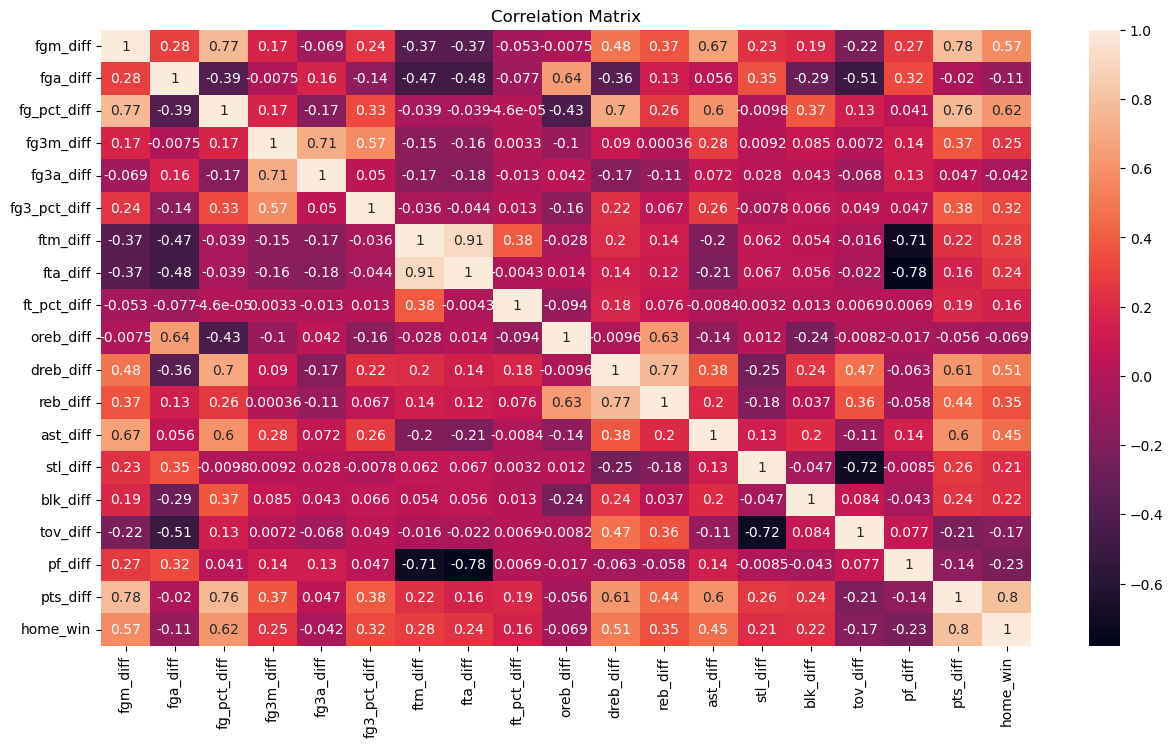

In [51]:
# Correlation between all Statistical Metrics in the Dataset 

correlation_matrix  = df_clean.corr(numeric_only = True)

plt.figure(figsize = (15,8))

sns.heatmap(correlation_matrix, annot = True)

plt.title('Correlation Matrix')

plt.show()

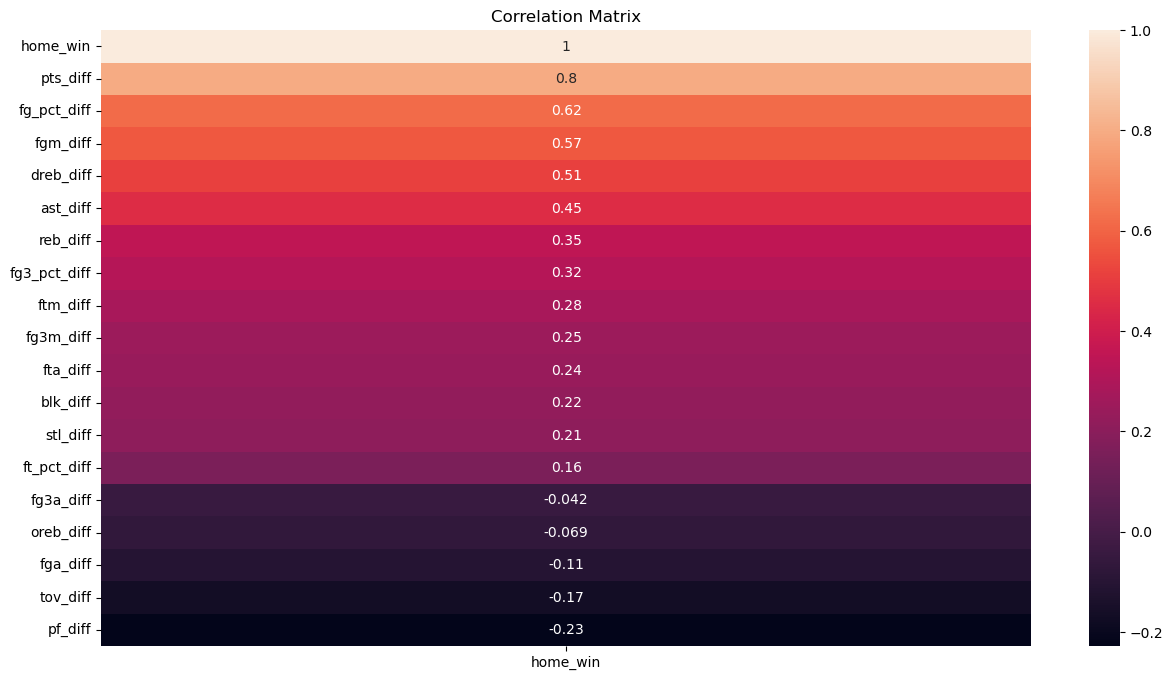

In [54]:
# Correlation Heatmap for what impacts winning 

corr_home = (
    df_clean.corr(numeric_only=True)[['home_win']]
      .sort_values('home_win', ascending=False)
)

plt.figure(figsize = (15,8))

sns.heatmap(corr_home, annot = True)

plt.title('Correlation Matrix')

plt.show()

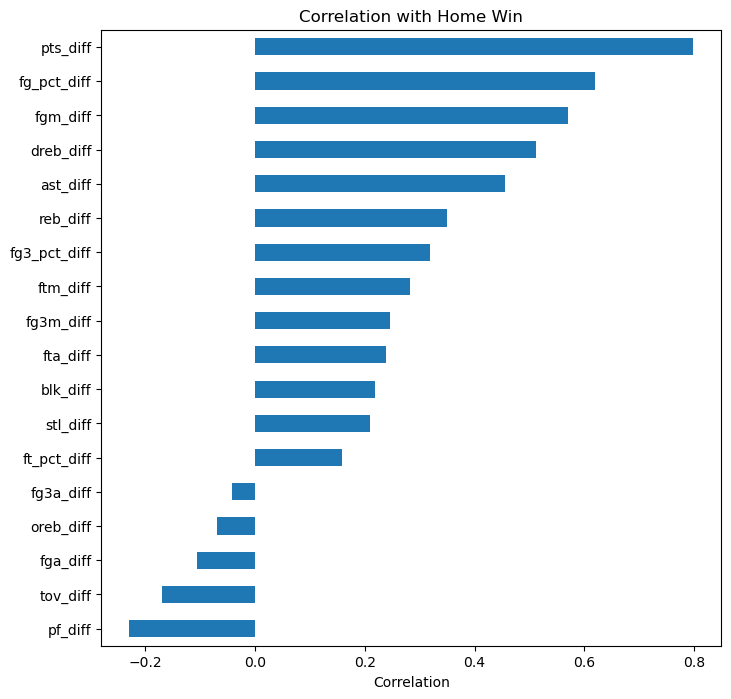

In [71]:
# Another way to represent the correlation statistics using 'Barh'

corr_home = (df_clean.corr(numeric_only=True)['home_win'].drop('home_win').sort_values()) # prepare a dataset

plt.figure(figsize=(8, 8))

corr_home.plot(kind='barh')

plt.title('Correlation with Home Win')
plt.xlabel('Correlation')
plt.show()

In [12]:
# Importing the table to Visualization in Tableau 

correlation_win = df_clean.corr(numeric_only = True)['home_win'].sort_values(ascending = False)

correlation_win.to_excel('Winning Factors.xlsx')
